Loaded 100 rows
Train size: 80
Test size: 20
Vectorized shape: (80, 398)
Model trained successfully!

Cross Validation Scores:
[0.8  0.6  0.8  0.7  0.75]

Mean CV Accuracy: 0.730

=== EVALUATION METRICS ===
Accuracy: 0.6500
Macro F1 Score: 0.6407

Classification Report:

              precision    recall  f1-score   support

 Electricity       0.67      0.50      0.57         4
       Roads       0.57      1.00      0.73         4
  Sanitation       0.67      0.50      0.57         4
   Transport       1.00      0.50      0.67         4
       Water       0.60      0.75      0.67         4

    accuracy                           0.65        20
   macro avg       0.70      0.65      0.64        20
weighted avg       0.70      0.65      0.64        20



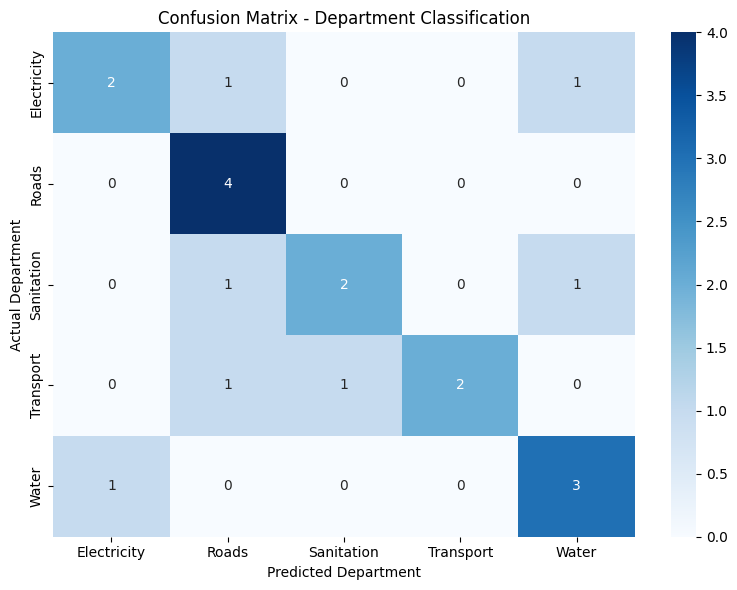


Model and vectorizer saved!

Sample Complaint:
street lights not working in my area
Predicted Department:
Electricity


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# =========================
# STEP 1: Load cleaned data
# =========================

df = pd.read_csv("../data/processed/grievances_cleaned.csv")

print(f"Loaded {len(df)} rows")

# =========================
# STEP 2: Define features and labels
# =========================

X = df["cleaned_text"]
y = df["department"]

# =========================
# STEP 3: Train-test split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")

# =========================
# STEP 4: TF-IDF Vectorization
# =========================

vectorizer = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Vectorized shape: {X_train_tfidf.shape}")

# =========================
# STEP 5: Train Logistic Regression model
# =========================

model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

print("Model trained successfully!")

# =========================
# STEP 6: Cross Validation
# =========================

cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42),
    vectorizer.transform(X),
    y,
    cv=5
)

print("\nCross Validation Scores:")
print(cv_scores.round(3))

print(f"\nMean CV Accuracy: {cv_scores.mean():.3f}")

# =========================
# STEP 7: Predictions
# =========================

y_pred = model.predict(X_test_tfidf)

print("\n=== EVALUATION METRICS ===")

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print(f"Macro F1 Score: {f1_score(y_test, y_pred, average='macro'):.4f}")

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

# =========================
# STEP 8: Confusion Matrix
# =========================

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix - Department Classification")

plt.xlabel("Predicted Department")

plt.ylabel("Actual Department")

plt.tight_layout()

plt.savefig("../data/processed/confusion_matrix.png")

plt.show()

# =========================
# STEP 9: Save model and vectorizer
# =========================

os.makedirs("../src", exist_ok=True)

with open("../src/model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("../src/vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("\nModel and vectorizer saved!")

# =========================
# STEP 10: Test custom prediction
# =========================

sample_text = ["street lights not working in my area"]

sample_vector = vectorizer.transform(sample_text)

prediction = model.predict(sample_vector)

print("\nSample Complaint:")

print(sample_text[0])

print("Predicted Department:")

print(prediction[0])  